<b>This is an example notebook which processed the raw DigiTraffic API -data</b>

#### In other words, this was the notebook that generated the "digitraffic_weather_balanced_ver1_2026.csv" -file!

#### Read comments and other instructions in order to see what happens in the data processing :)

In [1]:
# usual imports
import pandas as pd
import numpy as np
import seaborn as sns

<b>List all the data files from DigiTraffic => combine into single DataFrame with a loop</b>

In [2]:
from os import listdir
from os.path import isfile, join

# all separate data files are in the data-folder
mypath = "data/"

# list comprehension -> all files 
folder_files = [f for f in listdir(mypath) if isfile(join(mypath, f))]

# start with first data file and make it into our base DataFrame
# delete the first DataFrame from the list after that (because it's 
# already in our DataFrame as the first DataFrame)
df = pd.read_csv("data/" + folder_files[0])
del(folder_files[0])

# loop through the rest of the data files and add concat
# them after the existing DataFrames
for of in folder_files:
    temp_df = pd.read_csv("data/" + of)
    df = pd.concat([df, temp_df])

In [3]:
# check duplicates
df.duplicated().sum()

np.int64(376)

In [4]:
# remove duplicates
df = df.drop_duplicates()

#### Let's see current dataset 

In [5]:
# many of the columns are in Finnish, this code will rename
# to English after some processing
df

,KASTEPISTE,KESKITUULI,ILMAN_KOSTEUS,SADE,SADESUMMA,SATEEN_OLOMUOTO_PWDXX,TURVALLISUUSLÄMPÖ_1,ILMAN_LÄMPÖTILA_24H_MIN,ILMAN_LÄMPÖTILA_24H_MAX,LUMEN_SYVYYS,...,KITKA2,KITKA2_LUKU,SADESUMMA_LIUKUVA_24H,KOSTEUDEN_MÄÄRÄ_1,VALLITSEVA_SÄÄ,SADE_desc,SATEEN_OLOMUOTO_PWDXX_desc,KELI_1_desc,KELI_2_desc,stationId
0,-7.7,1.1,69.00,0.0,0.9,7.0,-0.7,-7.0,0.4,0.0,...,0.82,0.82,0.9,0.0,0.0,Dry weather,Dry weather,Probably moist and salty,The sensor has a fault,NaN
1,-8.7,1.2,59.00,0.0,0.0,7.0,NaN,-5.6,0.1,0.0,...,0.82,0.82,0.0,NaN,0.0,Dry weather,Dry weather,The sensor has a fault,Dry,NaN
2,-11.1,1.6,51.00,0.0,0.0,7.0,0.0,-8.5,0.4,0.0,...,0.82,0.82,0.0,0.0,0.0,Dry weather,Dry weather,Dry,NaN,NaN
3,-8.8,0.7,60.00,0.0,0.0,7.0,-0.3,-5.9,0.3,0.0,...,NaN,NaN,0.0,0.0,0.0,Dry weather,Dry weather,Dry,Dry,NaN
4,-12.1,0.9,47.00,0.0,0.0,7.0,0.0,-6.7,-0.5,0.0,...,NaN,NaN,0.0,0.0,0.0,Dry weather,Dry weather,Dry,Dry,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
518,0.9,NaN,98.53,NaN,NaN,7.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Dry weather,Moist,NaN,19966.0
519,4.2,NaN,91.96,NaN,0.0,7.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Dry weather,NaN,NaN,45002.0
521,3.0,NaN,84.56,NaN,0.0,7.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Dry weather,NaN,NaN,45004.0
522,1.1,NaN,100.00,NaN,0.0,7.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Dry weather,NaN,NaN,45005.0


<b>Missing values</b>

In [6]:
# a ridiculous amount of missing values, we have to process this somehow
df.isna().sum()

KASTEPISTE                      59
KESKITUULI                    1482
ILMAN_KOSTEUS                   79
SADE                           648
SADESUMMA                      555
SATEEN_OLOMUOTO_PWDXX          442
TURVALLISUUSLÄMPÖ_1           2568
ILMAN_LÄMPÖTILA_24H_MIN       2314
ILMAN_LÄMPÖTILA_24H_MAX       2314
LUMEN_SYVYYS                  4189
KELI_1                         970
KELI_2                        2664
KELI_3                        9273
KELI_4                        9339
VEDEN_MÄÄRÄ1                  5303
VEDEN_MÄÄRÄ2                  7377
LUMEN_MÄÄRÄ1                  5317
LUMEN_MÄÄRÄ2                  7377
JÄÄN_MÄÄRÄ1                   5303
JÄÄN_MÄÄRÄ2                   7377
JÄÄTAAJUUS_1                  1810
JÄÄTAAJUUS_2                  3050
KUURAPISTE                    2312
KUURAPISTE_ERO_ILMA           2312
KUURAPISTE_ERO_TIE            3180
KITKA1                        5303
KITKA1_LUKU                   5303
KITKA2                        7377
KITKA2_LUKU         

<b>Helper functions to combine similar variables and reducing amount of variables</b>
<p>For example, two variables for water => choose the one that has a value, otherwise remove the row (marked as NaN for removal later)</p>

In [7]:
# find a combo of these two if missing => use 0
# the main idea is to find at least one related variable
# and use that as a replacement
def determine_rain(row):
    if not pd.isna(row['VEDEN_MÄÄRÄ1']):
        return row['VEDEN_MÄÄRÄ1']
    elif not pd.isna(row['VEDEN_MÄÄRÄ2']):
        return row['VEDEN_MÄÄRÄ2']
    else:
        return np.nan
        

# find a combo of these two if missing => use 0
# the main idea is to find at least one related variable
# and use that as a replacement
def determine_snow(row):
    if not pd.isna(row['LUMEN_MÄÄRÄ1']):
        return row['LUMEN_MÄÄRÄ1']
    elif not pd.isna(row['LUMEN_MÄÄRÄ2']):
        return row['LUMEN_MÄÄRÄ2']
    else:
        return np.nan
        
# find a combo of these two if missing => use 0
# the main idea is to find at least one related variable
# and use that as a replacement
def determine_ice(row):
    if not pd.isna(row['JÄÄN_MÄÄRÄ1']):
        return row['JÄÄN_MÄÄRÄ1']
    elif not pd.isna(row['JÄÄN_MÄÄRÄ2']):
        return row['JÄÄN_MÄÄRÄ2']
    else:
        return np.nan

# find a combo of these two if missing => use 0
# the main idea is to find at least one related variable
# and use that as a replacement
def determine_friction(row):
    if not pd.isna(row['KITKA1']):
        return row['KITKA1']
    elif not pd.isna(row['KITKA2']):
        return row['KITKA2']
    else:
        return np.nan
    
# find a combo of these two if missing => use 0
# the main idea is to find at least one related variable
# and use that as a replacement
def determine_ice_freq(row):
    if not pd.isna(row['JÄÄTAAJUUS_1']):
        return row['JÄÄTAAJUUS_1']
    elif not pd.isna(row['JÄÄTAAJUUS_2']):
        return row['JÄÄTAAJUUS_2']
    else:
        return np.nan
    
# get mean temperature
def determine_mean_temp(row):
    value1 = row['ILMAN_LÄMPÖTILA_24H_MIN']
    value2 = row['ILMAN_LÄMPÖTILA_24H_MAX']

    if not pd.isna(value1) and not pd.isna(value2):
        return (value1 + value2) / 2
    elif pd.isna(value1):
        return value2
    else: 
        return value1

In [8]:
# remove unneeded columns and filter out NaNs from certain columns
droppables = ["SATEEN_OLOMUOTO_PWDXX", "KELI_1", "KELI_2", "KELI_3", "KELI_4", "KITKA1_LUKU", "KITKA2_LUKU", "stationId", "KUURAPISTE_ERO_ILMA", "KUURAPISTE_ERO_TIE", "TURVALLISUUSLÄMPÖ_1", "VALLITSEVA_SÄÄ"]
remove_nans = ["KASTEPISTE", "ILMAN_KOSTEUS", "KESKITUULI", "LUMEN_SYVYYS", "SADE", "SADESUMMA"]

# drop columns
df = df.drop(droppables, axis=1)
df = df.dropna(subset=(remove_nans))

In [9]:
# we're gonna use these target groups for our data
# group 1: Dry, no problem here
# group 2: Wet + Moist, should be okay
# group 3: Snow
# group 4: Ice + Frost + Freezing ... probably a few synthetic needs to be created

In [10]:
# helper column that combines all the text descriptions of the current weather
# this is used leater to determine the target output (based on groups above)
df['combos'] = df['SATEEN_OLOMUOTO_PWDXX_desc'] + "-" + df['KELI_1_desc'] + "-" + df['KELI_2_desc']

In [11]:
# let's check current columns
df.columns

Index(['KASTEPISTE', 'KESKITUULI', 'ILMAN_KOSTEUS', 'SADE', 'SADESUMMA',
       'ILMAN_LÄMPÖTILA_24H_MIN', 'ILMAN_LÄMPÖTILA_24H_MAX', 'LUMEN_SYVYYS',
       'VEDEN_MÄÄRÄ1', 'VEDEN_MÄÄRÄ2', 'LUMEN_MÄÄRÄ1', 'LUMEN_MÄÄRÄ2',
       'JÄÄN_MÄÄRÄ1', 'JÄÄN_MÄÄRÄ2', 'JÄÄTAAJUUS_1', 'JÄÄTAAJUUS_2',
       'KUURAPISTE', 'KITKA1', 'KITKA2', 'SADESUMMA_LIUKUVA_24H',
       'KOSTEUDEN_MÄÄRÄ_1', 'SADE_desc', 'SATEEN_OLOMUOTO_PWDXX_desc',
       'KELI_1_desc', 'KELI_2_desc', 'combos'],
      dtype='object')

#### Apply the helper functions defined earlier in order to have at least some value (if possible) for rain, snow, ice, friction etc.

In [12]:
# apply the custom functions to fix the variables
# and remove variables with similar purpose
df['rain_level'] = df.apply(determine_rain, axis=1)
df['snow_level'] = df.apply(determine_snow, axis=1)
df['ice_measure'] = df.apply(determine_ice, axis=1)
df['friction'] = df.apply(determine_friction, axis=1)
df['ice_frequency'] = df.apply(determine_ice_freq, axis=1)
df['mean_temperature'] = df.apply(determine_mean_temp, axis=1)

In [13]:
# and drop more columns
droppables = ['ILMAN_LÄMPÖTILA_24H_MIN', 'ILMAN_LÄMPÖTILA_24H_MAX', 
            'VEDEN_MÄÄRÄ1', 'VEDEN_MÄÄRÄ2', 'LUMEN_MÄÄRÄ1', 'LUMEN_MÄÄRÄ2',
            'JÄÄN_MÄÄRÄ1', 'JÄÄN_MÄÄRÄ2', 'JÄÄTAAJUUS_1', 'JÄÄTAAJUUS_2',
            'KITKA1', 'KITKA2']

In [14]:
# drop columns
df = df.drop(droppables, axis=1)

In [15]:
# missing values is looking better, but there's still work to do
df.isna().sum()

KASTEPISTE                       0
KESKITUULI                       0
ILMAN_KOSTEUS                    0
SADE                             0
SADESUMMA                        0
LUMEN_SYVYYS                     0
KUURAPISTE                     687
SADESUMMA_LIUKUVA_24H          687
KOSTEUDEN_MÄÄRÄ_1              656
SADE_desc                        0
SATEEN_OLOMUOTO_PWDXX_desc       0
KELI_1_desc                    362
KELI_2_desc                   1137
combos                        1179
rain_level                    1825
snow_level                    1825
ice_measure                   1825
friction                      1825
ice_frequency                  521
mean_temperature               687
dtype: int64

In [16]:
# use these to get one of the possibilities:
# Dry, Wet, Snow, Ice, Slush

# usable columns:
# SATEEN_OLOMUOTO_PWDXX_desc
# KELI_1_desc   
# KELI_2_desc
# SADE_desc

# the idea is this, if a certain word is present, use that as the output value
# in this case we have Snow, Ice, Rain or Normal.
# if nothing matches => NaN so we can remove these rows later
def determine_condition(row):
    value = str(row['combos'])
    if "Snow" in value:
        return "Snow"
    
    elif "Frost" in value or "Freezing" in value or "Ice" in value:
        return "Ice"
    
    elif "Wet" in value or "Moist" in value:
        return "Rain"

    elif "Dry" in value:
        return "Normal"
    else:
        return np.nan

In [17]:
# apply our custom function to get conditions
df['condition'] = df.apply(determine_condition, axis=1)

In [18]:
# oof, the distribution is very off, especially Ice is problematic
# we have to create synthetic data in order to bring up the Ice data
df['condition'].value_counts()

condition
Normal    2547
Rain      1272
Snow       792
Ice         30
Name: count, dtype: int64

In [19]:
# drop yet again some unneeded columns
droppables = ["SATEEN_OLOMUOTO_PWDXX_desc","KELI_1_desc", "KELI_2_desc"]
df = df.drop(droppables, axis=1)

In [20]:
# we don't need the text combo column anymore, we have the condition -column for this purpose
df = df.drop("combos", axis=1)

In [21]:
# .... aaand more column dropping
droppables = ["KUURAPISTE", "SADESUMMA_LIUKUVA_24H","KOSTEUDEN_MÄÄRÄ_1"]
df = df.drop(droppables, axis=1)

In [22]:
# still more work needed with this
df.isna().sum()

KASTEPISTE             0
KESKITUULI             0
ILMAN_KOSTEUS          0
SADE                   0
SADESUMMA              0
LUMEN_SYVYYS           0
SADE_desc              0
rain_level          1825
snow_level          1825
ice_measure         1825
friction            1825
ice_frequency        521
mean_temperature     687
condition           1194
dtype: int64

<b>Final touches, take a copy of the DataFrame just in case</b>

In [23]:
df2 = df.copy()
df2 = df2.dropna()

In [24]:
df2['condition'].value_counts()

condition
Normal    1749
Rain       896
Snow       512
Ice         15
Name: count, dtype: int64

In [25]:
df2.columns

Index(['KASTEPISTE', 'KESKITUULI', 'ILMAN_KOSTEUS', 'SADE', 'SADESUMMA',
       'LUMEN_SYVYYS', 'SADE_desc', 'rain_level', 'snow_level', 'ice_measure',
       'friction', 'ice_frequency', 'mean_temperature', 'condition'],
      dtype='object')

In [26]:
# drop unneeded column
df2 = df2.drop("SADE_desc", axis=1)

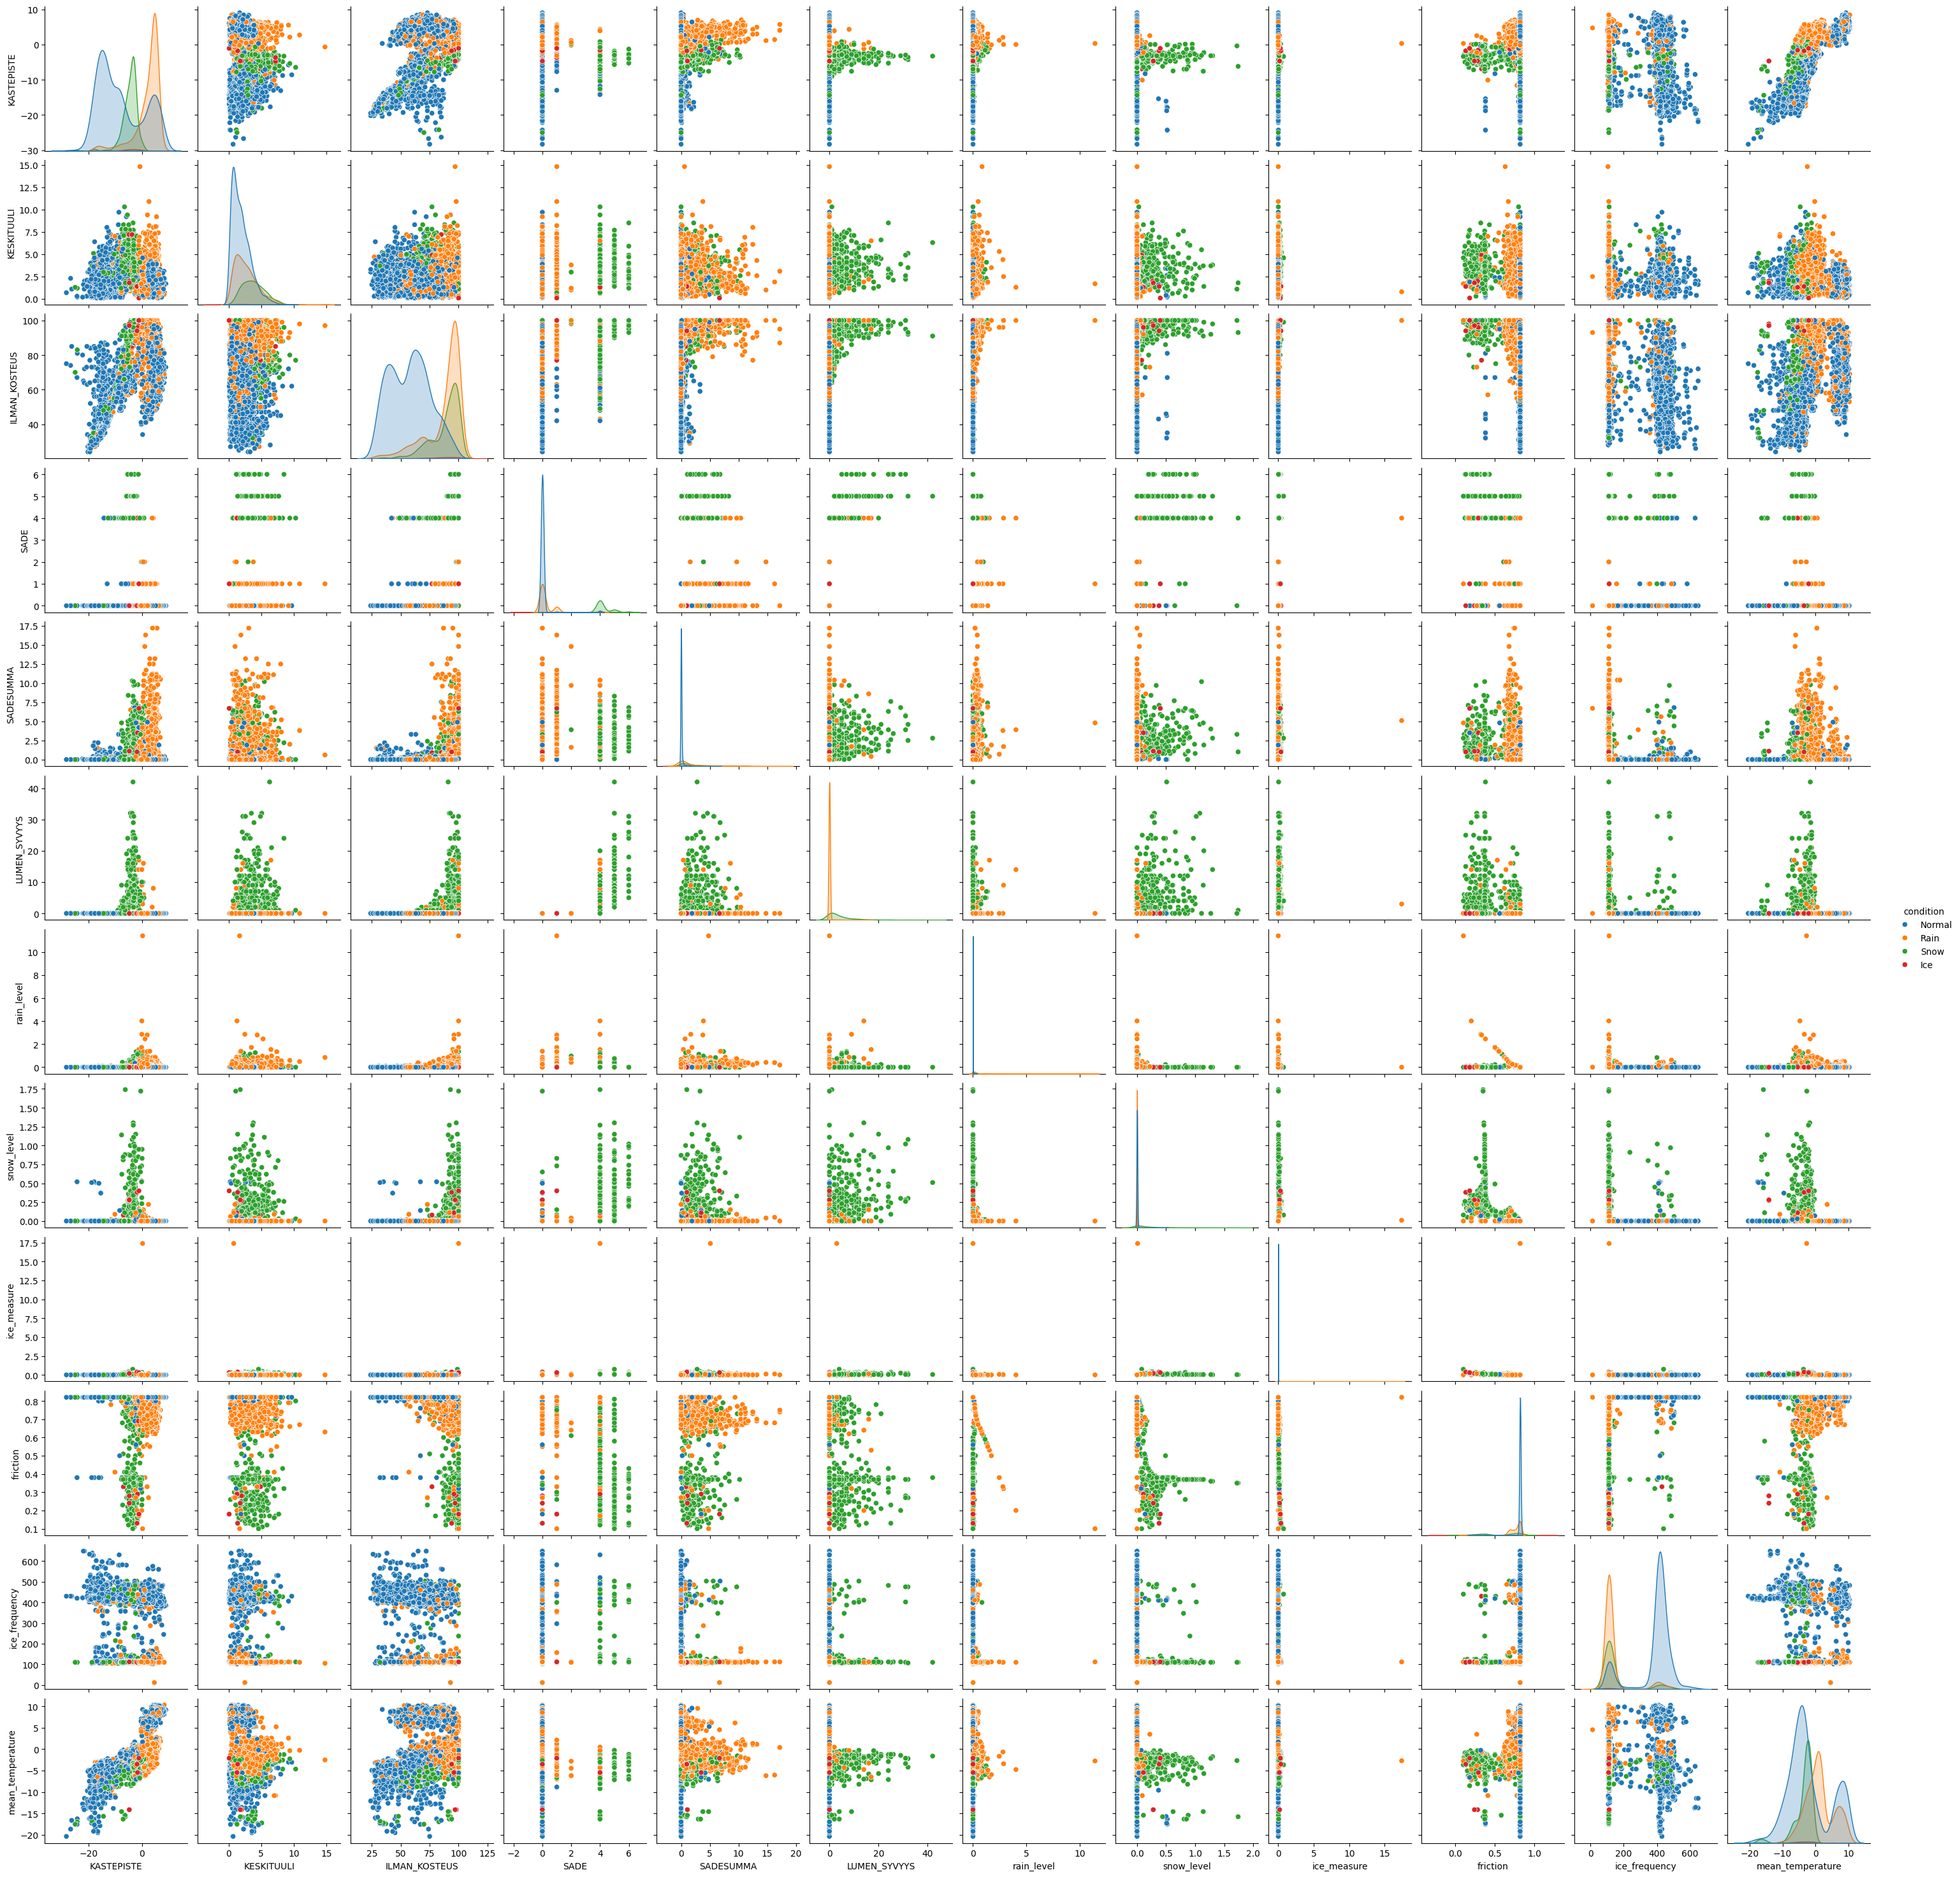

In [27]:
# we can see with the distributions that
# the different classes are different from each
# other, which is good, and we can expect a decent classification result in ML
sns.pairplot(df2, hue="condition")

In [28]:
# current columns, I think we should finally rename these to English
df2.columns

Index(['KASTEPISTE', 'KESKITUULI', 'ILMAN_KOSTEUS', 'SADE', 'SADESUMMA',
       'LUMEN_SYVYYS', 'rain_level', 'snow_level', 'ice_measure', 'friction',
       'ice_frequency', 'mean_temperature', 'condition'],
      dtype='object')

In [29]:
# rename columns to English 
df2 = df2.rename({"KASTEPISTE": "dew_point", "KESKITUULI": "avg_wind", "ILMAN_KOSTEUS": "humidity", "SADE": "rain", "SADESUMMA": "rain_sum", "LUMEN_SYVYYS": "snow_depth","snow_level": "snow_amount", "rain_level": "rain_amount"}, axis=1)

In [30]:
# looking good!
df2.columns

Index(['dew_point', 'avg_wind', 'humidity', 'rain', 'rain_sum', 'snow_depth',
       'rain_amount', 'snow_amount', 'ice_measure', 'friction',
       'ice_frequency', 'mean_temperature', 'condition'],
      dtype='object')

<b>Data synthetization: We need more Ice-data</b>

In [31]:
# let's see some average statistics for the ice conditions (which are very few in data)
df2[df2['condition'] == "Ice"].describe()

,dew_point,avg_wind,humidity,rain,rain_sum,snow_depth,rain_amount,snow_amount,ice_measure,friction,ice_frequency,mean_temperature
count,15.000000,15.000000,15.000000,15.000000,15.000000,15.0,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000
mean,-4.913333,2.826667,85.800000,1.066667,1.566667,0.0,0.070667,0.108667,0.098667,0.558667,131.533333,-4.763333
std,4.030042,2.196577,14.067186,1.279881,1.788721,0.0,0.091921,0.147254,0.121706,0.273832,82.609984,4.203547
min,-14.300000,0.100000,49.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.130000,105.000000,-14.150000
25%,-5.600000,1.350000,81.000000,0.000000,0.550000,0.0,0.000000,0.000000,0.000000,0.285000,109.500000,-5.525000
50%,-3.700000,2.000000,90.000000,1.000000,1.000000,0.0,0.010000,0.040000,0.050000,0.720000,110.000000,-3.400000
75%,-2.200000,3.650000,96.500000,1.000000,1.750000,0.0,0.155000,0.190000,0.160000,0.775000,112.000000,-1.950000
max,-1.100000,7.200000,100.000000,4.000000,6.700000,0.0,0.250000,0.400000,0.380000,0.820000,430.000000,-1.300000


In [32]:
# the idea: synthesize 400 more ice conditions by using 
# the average statistics
df2['condition'].value_counts()

condition
Normal    1749
Rain       896
Snow       512
Ice         15
Name: count, dtype: int64

In [33]:
# filter only ice-conditions out of the data
df_ice = df2[df2['condition'] == "Ice"]

# this was just used to create basic statistics into 
# a nice text list, and this was then given to ChatGPT
for column in df_ice.columns:
    if column == "condition":
        continue

    print(column)
    print(df_ice.describe().loc[['mean', 'min','max','std']][column])
    print()

dew_point
mean    -4.913333
min    -14.300000
max     -1.100000
std      4.030042
Name: dew_point, dtype: float64

avg_wind
mean    2.826667
min     0.100000
max     7.200000
std     2.196577
Name: avg_wind, dtype: float64

humidity
mean     85.800000
min      49.000000
max     100.000000
std      14.067186
Name: humidity, dtype: float64

rain
mean    1.066667
min     0.000000
max     4.000000
std     1.279881
Name: rain, dtype: float64

rain_sum
mean    1.566667
min     0.000000
max     6.700000
std     1.788721
Name: rain_sum, dtype: float64

snow_depth
mean    0.0
min     0.0
max     0.0
std     0.0
Name: snow_depth, dtype: float64

rain_amount
mean    0.070667
min     0.000000
max     0.250000
std     0.091921
Name: rain_amount, dtype: float64

snow_amount
mean    0.108667
min     0.000000
max     0.400000
std     0.147254
Name: snow_amount, dtype: float64

ice_measure
mean    0.098667
min     0.000000
max     0.380000
std     0.121706
Name: ice_measure, dtype: float64

friction
me

<b>ChatGPT was used to create random new Ice-rows by using the basic statistics for each variable</b>
<p>Basically, mimicing the behavior of real Ice-data, but using normal distribution and random</p>

In [34]:
# Define the statistics for each column
column_stats = {
    'dew_point': {'mean': -4.913333, 'std': 4.030042, 'min': -14.3, 'max': -1.1},
    'avg_wind': {'mean': 2.826667, 'std': 2.196577, 'min': 0.1, 'max': 7.2},
    'humidity': {'mean': 85.8, 'std': 14.067186, 'min': 49.0, 'max': 100.0},
    'rain': {'mean': 1.066667, 'std': 1.279881, 'min': 0.0, 'max': 4.0},
    'rain_sum': {'mean': 1.566667, 'std': 1.788721, 'min': 0.0, 'max': 6.7},
    'snow_depth': {'mean': 0.0, 'std': 0.0, 'min': 0.0, 'max': 0.0},
    'rain_amount': {'mean': 0.070667, 'std': 0.091921, 'min': 0.0, 'max': 0.25},
    'snow_amount': {'mean': 0.108667, 'std': 0.147254, 'min': 0.0, 'max': 0.4},
    'ice_measure': {'mean': 0.098667, 'std': 0.121706, 'min': 0.0, 'max': 0.38},
    'friction': {'mean': 0.558667, 'std': 0.273832, 'min': 0.13, 'max': 0.82},
    'ice_frequency': {'mean': 131.533333, 'std': 82.609984, 'min': 105.0, 'max': 430.0},
    'mean_temperature': {'mean': -4.763333, 'std': 4.203547, 'min': -14.15, 'max': -1.3}
}

# Number of synthetic data rows to generate
n_rows = 400

# Initialize an empty DataFrame to store the synthetic data
df_synthetic = pd.DataFrame()

# Generate synthetic data for each column
for column, stats in column_stats.items():
    mean = stats['mean']
    std = stats['std']
    min_val = stats['min']
    max_val = stats['max']
    
    # Generate data using normal distribution
    data = np.random.normal(loc=mean, scale=std, size=n_rows)
    
    # Clip the data to the min/max range to avoid extreme outliers
    data = np.clip(data, min_val, max_val)
    
    # Add the generated data to the DataFrame
    df_synthetic[column] = data



In [35]:
# let's see the statistics, they're a little bit off from the original ones (ice-condition)
# even though not optimal, better than nothing!
df_synthetic.describe()

,dew_point,avg_wind,humidity,rain,rain_sum,snow_depth,rain_amount,snow_amount,ice_measure,friction,ice_frequency,mean_temperature
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.0,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,-5.289988,3.087760,84.754110,1.193307,1.731261,0.0,0.081748,0.129514,0.118321,0.539945,153.792883,-5.389818
std,3.278942,1.951124,12.136242,1.066237,1.480587,0.0,0.071993,0.114346,0.099395,0.220251,57.100072,3.472954
min,-14.300000,0.100000,49.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.130000,105.000000,-14.150000
25%,-7.197173,1.488755,76.251722,0.211558,0.473649,0.0,0.014073,0.015461,0.024960,0.366342,105.000000,-7.678921
50%,-5.230150,3.063255,85.777333,0.983404,1.468805,0.0,0.070501,0.116929,0.112967,0.552430,135.033530,-5.040721
75%,-2.522498,4.497141,95.604614,1.900362,2.694879,0.0,0.136274,0.205996,0.189997,0.742208,187.941733,-2.055198
max,-1.100000,7.200000,100.000000,4.000000,6.467412,0.0,0.250000,0.400000,0.380000,0.820000,394.871875,-1.300000


In [36]:
df2.describe()

,dew_point,avg_wind,humidity,rain,rain_sum,snow_depth,rain_amount,snow_amount,ice_measure,friction,ice_frequency,mean_temperature
count,3172.000000,3172.000000,3172.000000,3172.000000,3172.000000,3172.000000,3172.000000,3172.000000,3172.000000,3172.000000,3172.000000,3172.000000
mean,-4.444294,2.457976,71.278058,0.784363,0.907188,0.771122,0.074615,0.031948,0.019596,0.757339,277.123266,-1.449590
std,8.107840,1.735751,22.011255,1.606957,2.033201,3.079512,0.275038,0.131821,0.312425,0.143120,159.805904,5.657284
min,-28.300000,0.100000,24.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.100000,12.000000,-20.400000
25%,-12.100000,1.100000,54.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.777500,112.000000,-4.950000
50%,-3.600000,2.100000,72.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.820000,382.000000,-2.500000
75%,3.625000,3.400000,93.000000,0.000000,0.700000,0.000000,0.050000,0.000000,0.000000,0.820000,422.000000,1.300000
max,9.000000,14.800000,100.000000,6.000000,17.200000,42.000000,11.420000,1.740000,17.390000,0.820000,648.000000,10.350000


In [37]:
# set the condition of synthetic data to Ice
df_synthetic['condition'] = "Ice"

In [38]:
# add the synthetic Ice-data to the original data
df3 = pd.concat([df2, df_synthetic])

In [39]:
# distribution is better, but normal and rain are over-represented
# we have to do DOWNSAMPLING for Normal and rain
df3['condition'].value_counts()

condition
Normal    1749
Rain       896
Snow       512
Ice        415
Name: count, dtype: int64

<b>Downsampling, code originally from ChatGPT</b>

In [40]:
# Step 1: Separate the data into four dataframes based on the weather classes
df_normal = df3[df3['condition'] == 'Normal']
df_rain = df3[df3['condition'] == 'Rain']
df_snow = df3[df3['condition'] == 'Snow']
df_ice = df3[df3['condition'] == 'Ice']

# Step 2: Downsample the over-represented classes to approximately 600 rows using quantiles
target_size = 600

# Downsample Normal and Rain
df_normal_downsampled = df_normal.sample(n=target_size, random_state=42)
df_rain_downsampled = df_rain.sample(n=target_size, random_state=42)

# Step 3: Concatenate the downsampled dataframes back together to create a balanced dataset
df_balanced = pd.concat([df_normal_downsampled, df_rain_downsampled, df_snow, df_ice], ignore_index=True)

# Shuffle the dataset
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# Display the value counts of the weather classes in the balanced dataset
print(df_balanced['condition'].value_counts())

# distributions look nice now

condition
Normal    600
Rain      600
Snow      512
Ice       415
Name: count, dtype: int64


In [41]:
# no missing values
df_balanced.isna().sum()

dew_point           0
avg_wind            0
humidity            0
rain                0
rain_sum            0
snow_depth          0
rain_amount         0
snow_amount         0
ice_measure         0
friction            0
ice_frequency       0
mean_temperature    0
condition           0
dtype: int64

In [42]:
# you can save the current version of the data to file now
df_balanced.to_csv("digitraffic_weather_balanced_ver1_2026.csv", index=False)